<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 15 (diagnostic only, not in `run_all.py`) — Pipeline Diagnostic Review

**สถานะ:** ✅ ใช้งานจริงในฐานะ diagnostic — **ไม่ได้ถูกเรียกจาก `pipeline/run_all.py`** (ไม่อยู่ใน `CHAIN`
หรือ `POST` list); รันแยกด้วยมือเพื่อรีวิวผลลัพธ์ของ pipeline ทั้งหมด ไม่ใช่ automated dependency

**ตอบคำถามอะไร:** ไล่ทบทวน step 0 → 6d ทั้งหมด, โหลดผลลัพธ์ที่คำนวณไว้แล้ว (ไม่คำนวณใหม่), plot diagnostic
+ สรุป Analysis/Recommendation ต่อท้ายทุก step

**Input:** ผลลัพธ์ที่มีอยู่แล้วจาก `CPHT_DATA_DIR`, `outputs/`, `dashboard/data/`, `models/` (อ่านอย่างเดียว
ไม่เขียนทับอะไร)

**Output:** ไม่มีไฟล์ output — เป็น review notebook ล้วน ๆ

**แดชบอร์ด:** ไม่เกี่ยวข้อง — ไม่มี consumer downstream ใด ๆ

**หมายเหตุ:** ดู `docs/ARCHIVE_CANDIDATES.md` — จัดเป็น "diagnostic consumer only", ไม่ใช่ orphan ที่ต้อง
archive แต่ก็ไม่ใช่ production chain

---


# Pipeline Diagnostic Review / รีวิวขั้นตอนการวิเคราะห์ทั้ง Pipeline (Step 0 → 6d)

**วัตถุประสงค์ / Objective:** ไล่ทบทวนทุกขั้นตอนของ pipeline การวิเคราะห์ fouling/CIT ของ Crude Preheat Train
(CPHT) ตั้งแต่ data profiling จนถึง ML model benchmarking — โหลดผลลัพธ์จริงที่คำนวณไว้แล้วของแต่ละ step,
plot กราฟวินิจฉัย (diagnostic plot), แล้วสรุป **Analysis** (สิ่งที่กราฟบอก) และ **Recommendation**
(แนวทางแก้ไข/ข้อควรระวัง) ต่อท้ายทุก step.

This notebook does **not** recompute the pipeline — it loads the real, already-computed outputs
(from `CPHT_DATA_DIR`, `outputs/`, `dashboard/data/`, `models/`) and reuses the shared helper modules
`cpht_config.py`, `cpht_features.py`, `nb_audit.py` (same single-source-of-truth pattern as notebooks 2a-6d).
See `METHODOLOGY.md` for the full narrative this review is condensed from.


In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

REPO_ROOT = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
sys.path.append(str(REPO_ROOT))

import src.domain.config as C
import src.features.heat_duty as F
import src.validation.nb_audit as A

sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams.update({'figure.dpi': 100})

DATA_DIR  = Path(C.DATA_DIR)
OUT_DIR   = REPO_ROOT / 'outputs'
DASH_DIR  = REPO_ROOT / 'dashboard' / 'data'
MODEL_DIR = REPO_ROOT / 'models'

def load(name, **kw):
    return pd.read_csv(DATA_DIR / name, **kw)

def load_out(name, **kw):
    return pd.read_csv(OUT_DIR / name, **kw)

def load_json(name, base=DASH_DIR):
    with open(base / name) as f:
        return json.load(f)

print('CPHT_DATA_DIR =', DATA_DIR)


CPHT_DATA_DIR = C:\Desktop\Bangchak Internship 2026\Data


## Step 0 — Data Profiling / การสำรวจข้อมูลดิบ
**Notebooks:** `_eda_process_control.ipynb`, `_eda_crude_assay.ipynb` (เปลี่ยนชื่อ Phase 1 จาก `00_data_prep_process_control.ipynb`/`00_data_prep_crude_assay.ipynb`)
**Method:** ไม่มีโมเดล — เป็นการสำรวจคุณภาพข้อมูล (missing %, distribution, correlation) ก่อนเข้าสู่ pipeline
**Data:** `Process_information_with_crude.csv` (ข้อมูล process control ดิบ), `Crude_property_profiled.csv` (คุณสมบัติน้ำมันดิบรายวัน)

── Data-quality report: Process_information_with_crude ──
   rows=836  cols=103  duplicate_rows=0  time_gaps>D=1


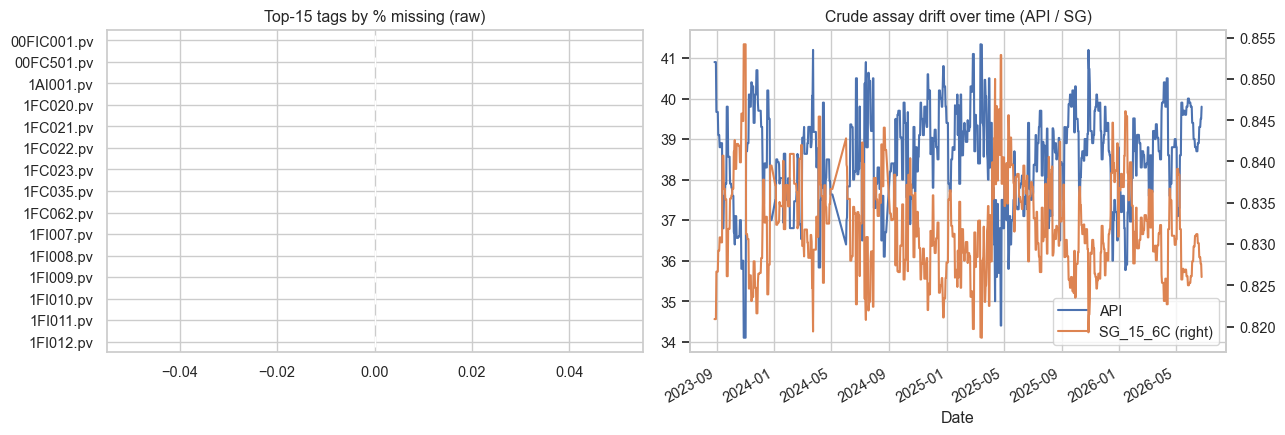

In [2]:
raw = pd.read_csv(os.path.join(DATA_DIR, 'Process_information_with_crude.csv'),
                   index_col='Timestamp', parse_dates=True)
crude = pd.read_csv(os.path.join(DATA_DIR, 'Crude_property_profiled.csv'), parse_dates=['Date'])

qr = A.data_quality_report(raw, name='Process_information_with_crude', expected_freq='D')
qr_worst = qr.sort_values('missing_%', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
qr_worst['missing_%'].plot.barh(ax=axes[0], color='#c0392b')
axes[0].set_title('Top-15 tags by % missing (raw)')
axes[0].invert_yaxis()

crude.set_index('Date')[['API', 'SG_15_6C']].plot(ax=axes[1], secondary_y='SG_15_6C')
axes[1].set_title('Crude assay drift over time (API / SG)')
plt.tight_layout(); plt.show()


**Analysis:** ตรวจสอบว่า tag ไหนมี missing สูงผิดปกติ (จะกระทบ feature ที่พึ่งพา tag นั้นใน step ถัดไป)
และดูว่าคุณสมบัติน้ำมันดิบ (API/SG) เปลี่ยนแปลงข้ามช่วงเวลา — เป็นสาเหตุหลักของ "multi-month level drift"
ใน CIT ที่ step 6a ต้องแก้ด้วย crude-assay feature.

**Recommendation:** tag ที่ missing สูง (>20-30%) ควรถูก flag ก่อนใช้ในการคำนวณ Q/fouling (step 2) — ถ้า
`data_quality_report` ด้านบนแสดง tag สำคัญ (crude temp, flow) มี missing สูง ให้ตรวจ step 1 ว่า cleaning
จัดการอย่างไร ก่อนเชื่อผลลัพธ์ปลายทาง.


## Step 1 — Cleaning: TAM detection + sensor-outlier correction / การทำความสะอาดข้อมูล
**Notebook:** `01_data_cleaning.ipynb`
**Method:** Rule-based — rolling 30-day anomaly detection (TAM/shutdown window), rolling z-score +
chain-consistency check (`cold_out < cold_in - tol`) for sensor faults (see [[project_cold_side_outlier_fill]])
**Data:** `Process_information_with_crude.csv` (before) vs `Process_information_cleaned.csv` (after)


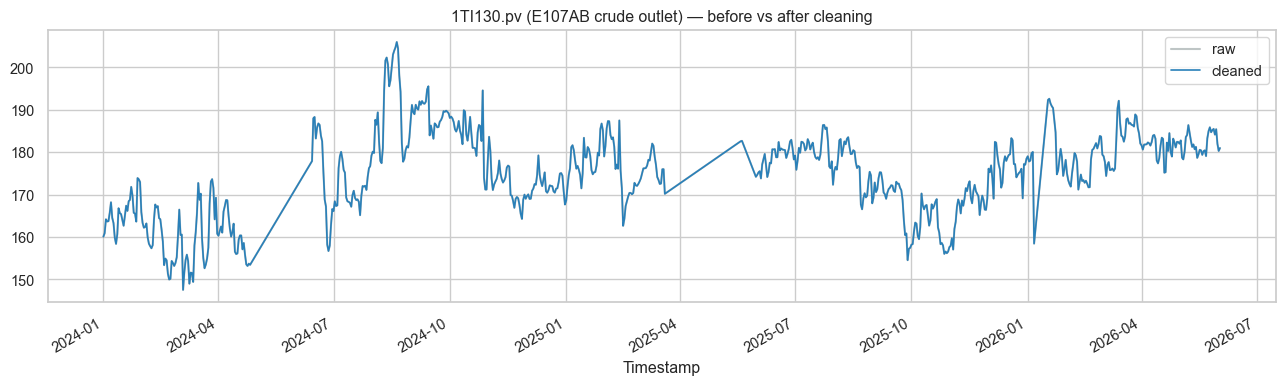

rows raw: 836  rows cleaned: 836  rows removed (TAM/shutdown): 0


In [3]:
cleaned = pd.read_csv(os.path.join(DATA_DIR, 'Process_information_cleaned.csv'),
                      index_col='Timestamp', parse_dates=True)

# 1TI130.pv: known multi-week sensor fault the rolling z-score alone missed
tag = '1TI130.pv'
fig, ax = plt.subplots(figsize=(13, 4))
raw[tag].plot(ax=ax, alpha=0.5, label='raw', color='#7f8c8d')
if tag in cleaned.columns:
    cleaned[tag].plot(ax=ax, label='cleaned', color='#2980b9', lw=1.2)
ax.set_title(f'{tag} (E107AB crude outlet) — before vs after cleaning')
ax.legend(); plt.tight_layout(); plt.show()

print('rows raw:', len(raw), ' rows cleaned:', len(cleaned),
      ' rows removed (TAM/shutdown):', len(raw) - len(cleaned))


**Analysis:** เส้น "cleaned" ควรจะเรียบขึ้นในช่วงที่ raw มีสัญญาณผิดปกติหลายสัปดาห์ — ถ้า chain-consistency
check ทำงานถูกต้อง fault ที่ rolling z-score เพียงอย่างเดียวตรวจไม่พบ (เพราะ fault ครอบคลุมทั้ง window ของมันเอง)
จะถูกแก้ไข ส่วนจำนวนแถวที่ถูกตัดออกคือช่วง TAM/shutdown ที่ไม่ใช่ operating data ปกติ

**Recommendation:** วิธีนี้ครอบคลุมเฉพาะ sensor fault ที่ทำให้ cold_out < cold_in (physically impossible) —
sensor fault ประเภทอื่น (เช่น drift แบบช้าที่ยังคง physically plausible) จะไม่ถูกตรวจจับ ควรพิจารณาเพิ่ม
cross-check กับ tag ข้างเคียงถ้าพบว่าผลลัพธ์ปลายทาง (fouling rate) ของ HX ใดผิดปกติผิดสังเกต.


## Step 2 — Feature Engineering: Q duty, correlation, PCA / การคำนวณ Feature
**Notebooks:** `02_feature_engineering.ipynb`, `2_correlation.ipynb`, `2_pca.ipynb`
**Method:** Physics-based Q = ρ·flow·Cp·ΔT (cold-side only, Cp=2.2 kJ/kg·K, ρ=850 kg/m³ — **fixed assumed
constants**, not measured); PCA/Pearson-Spearman correlation are exploratory only, no predictive model
**Data:** `Feature_calculated.csv` (380 cols: raw tags + per-HX Rf_run/U_relative/days_on_duty)


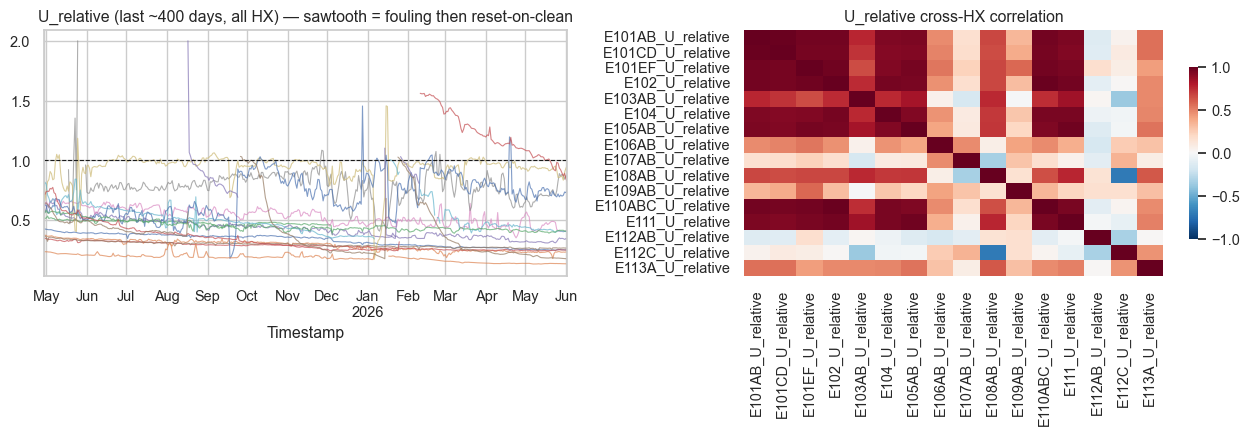

In [4]:
fc = pd.read_csv(os.path.join(DATA_DIR, 'Feature_calculated.csv'),
                  index_col='Timestamp', parse_dates=True)

hx_list = list(C.HX_CONFIG.keys())
u_cols = [f'{hx}_U_relative' for hx in hx_list if f'{hx}_U_relative' in fc.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fc[u_cols].iloc[-400:].plot(ax=axes[0], legend=False, lw=0.8, alpha=0.7)
axes[0].set_title('U_relative (last ~400 days, all HX) — sawtooth = fouling then reset-on-clean')
axes[0].axhline(1.0, color='k', ls='--', lw=0.8)

corr = fc[u_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='RdBu_r', vmin=-1, vmax=1, cbar_kws={'shrink': 0.7})
axes[1].set_title('U_relative cross-HX correlation')
plt.tight_layout(); plt.show()


**Analysis:** รูปแบบ sawtooth (U_relative ลดลงเรื่อยๆ แล้วเด้งกลับ 1.0 เมื่อ HX ถูกทำความสะอาด/สลับ shell)
คือสัญญาณ fouling ที่แท้จริง ใช้เป็น ground-truth proxy เพราะไม่มีการวัด fouling resistance (Rf) โดยตรง
Cross-HX correlation สูงในบาง HX มักเป็นเพราะใช้ crude flow ร่วมกัน (`flow_source: shared with ...` ใน
`cpht_config.py`) ไม่ใช่ fouling ที่สัมพันธ์กันจริง

**Recommendation:** Cp/ρ คงที่ใช้ได้เฉพาะการเปรียบเทียบ **สัมพัทธ์** (U_relative, Q_drop %) ห้ามใช้ค่า Q
สัมบูรณ์ (kW) เป็นตัวเลขวิศวกรรมจริงโดยไม่ปรับด้วยคุณสมบัติน้ำมันดิบจริงในแต่ละช่วงเวลา.


## Step 2a — Operating State Classification / การจำแนกสถานะการทำงาน
**Notebook:** `03_operating_state_classification.ipynb`
**Method:** Rule-based state machine (CPHT-1/CPHT-2 train grouping, active-shell logic for parallel shells)
**Data:** `Operating_State.csv`


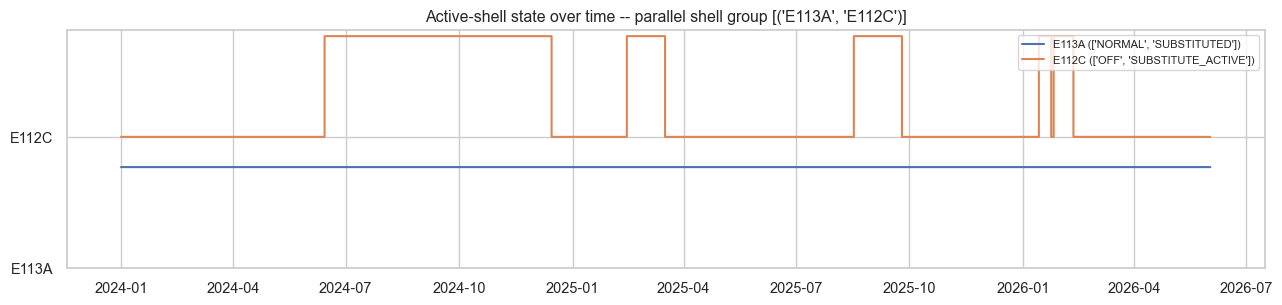

In [5]:
os_df = pd.read_csv(os.path.join(DATA_DIR, 'Operating_State.csv'),
                     index_col='Timestamp', parse_dates=True)

parallel_cols = [c for grp in C.PARALLEL_SHELL_GROUPS for c in grp if c in os_df.columns]
fig, ax = plt.subplots(figsize=(13, 3.2))
for i, c in enumerate(parallel_cols):
    # states are categorical labels (e.g. NORMAL/OFF/SUBSTITUTED) -- 'active' means
    # anything other than the idle/off label for that column
    idle_labels = {'OFF'}
    active = (~os_df[c].isin(idle_labels)).astype(float)
    ax.step(os_df.index, active + i * 1.3, where='post', label=f'{c} ({os_df[c].unique().tolist()})')
ax.set_yticks([i * 1.3 for i in range(len(parallel_cols))]); ax.set_yticklabels(parallel_cols)
ax.set_title('Active-shell state over time -- parallel shell group ' + str(C.PARALLEL_SHELL_GROUPS))
ax.legend(loc='upper right', fontsize=8); plt.tight_layout(); plt.show()


**Analysis:** E113A/E112C เป็น parallel shell คู่เดียวกัน — ต้องมี "active shell" เพียงตัวเดียวในเวลาใดเวลา
หนึ่ง (ใช้ max ไม่ใช่ min เพราะ spare shell ที่ idle จะมีค่า flow/duty ต่ำ ไม่ใช่ active) กราฟควรแสดงการสลับ
กันเป็นช่วงๆ ไม่ทับซ้อนกันตลอดเวลา

**Recommendation:** ถ้าพบช่วงเวลาที่ทั้งสอง shell แสดงเป็น "active" พร้อมกันเป็นเวลานาน ให้ตรวจสอบ threshold
การจำแนกใน 2a อีกครั้ง — ปัจจุบันยืนยันแล้วว่า logic ถูกต้อง (per [[project_operating_state_classification]]).


## Step 2b/2c — Q Duty, Fouling Rate Ranking, Q–CIT Sensitivity
**Notebooks:** `04_fouling_rate_estimation.ipynb`, `05_fouling_cit_sensitivity.ipynb`
**Method:** Statistical (Pearson/Spearman correlation, partial correlation controlling for total charge
rate) — **no ML model**
**Data:** `Feature_Q.csv`, `Fouling_Rate_Ranking.csv`, `Q_CIT_Sensitivity.csv`


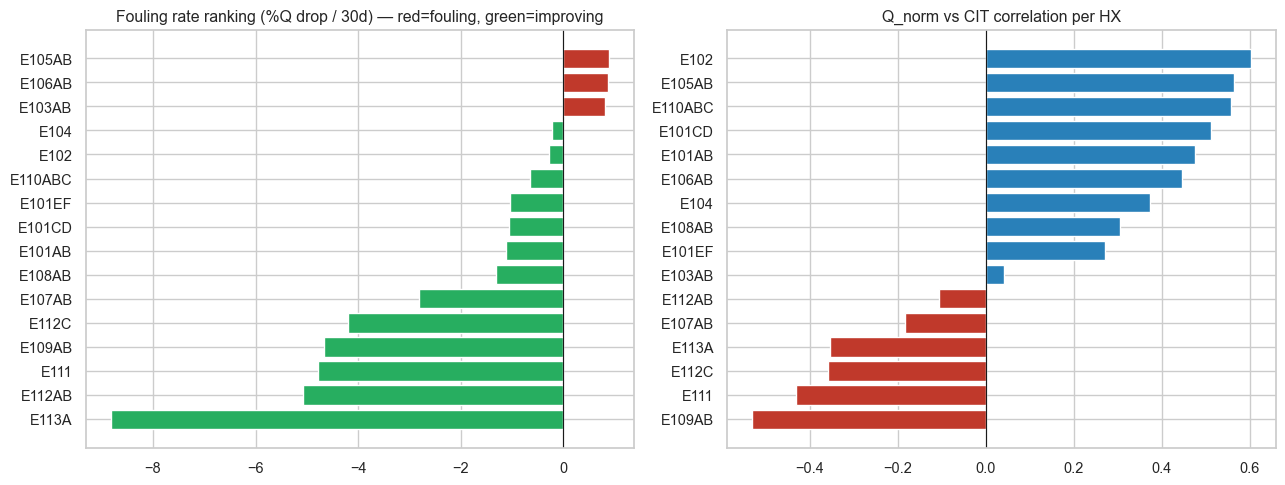

In [6]:
fq = pd.read_csv(os.path.join(DATA_DIR, 'Feature_Q.csv'), index_col='Timestamp', parse_dates=True)
fr = pd.read_csv(os.path.join(DATA_DIR, 'Fouling_Rate_Ranking.csv'))
qcit = pd.read_csv(os.path.join(DATA_DIR, 'Q_CIT_Sensitivity.csv'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fr_sorted = fr.sort_values('median_pct_drop_per_30d')
colors = ['#27ae60' if v < 0 else '#c0392b' for v in fr_sorted['median_pct_drop_per_30d']]
axes[0].barh(fr_sorted['HX'], fr_sorted['median_pct_drop_per_30d'], color=colors)
axes[0].set_title('Fouling rate ranking (%Q drop / 30d) — red=fouling, green=improving')
axes[0].axvline(0, color='k', lw=0.8)

qcit_sorted = qcit.sort_values('Q_CIT_corr')
colors2 = ['#c0392b' if v < 0 else '#2980b9' for v in qcit_sorted['Q_CIT_corr']]
axes[1].barh(qcit_sorted['HX'], qcit_sorted['Q_CIT_corr'], color=colors2)
axes[1].set_title('Q_norm vs CIT correlation per HX')
axes[1].axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()


**Analysis:** HX ตำแหน่งท้ายสุดของ train (E113A, E112C, E111, E109AB) มักแสดง Q-CIT correlation เป็น
**ลบ** — นี่คือ pinch effect จริง (ยิ่ง duty สูง ยิ่งดึงความร้อนออกจาก residue ที่เหลือน้อยลง) ไม่ใช่ confound
ทางสถิติ (per [[project_2bcd_cleaning_ranking_pipeline]]) ดังนั้นการให้คะแนน priority ใน step 2d จึงต้องปรับ
ด้วย coking-risk/chain-position ไม่ใช่ใช้ correlation ดิบตรงๆ

**Recommendation:** ใช้กราฟนี้ยืนยันว่า HX ปลายสายที่ correlation ติดลบไม่ควรถูกลดความสำคัญ — เป็นเหตุผลที่
step 2d ต้องเพิ่ม coking-risk score เข้ามาชดเชย.


## Step 2d — Cleaning Priority Ranking: v1 vs v2 / การจัดลำดับความสำคัญ
**Notebook:** `08_cleaning_priority_ranking.ipynb`
**Method:** Weighted rule-based score. v1 = min-max normalized (Q-fouling + CIT-importance).
v2 (redesigned) = rank-percentile normalized, Q-duty-shortfall weighted as primary consequence
term (CIT weight reduced to 0.25) — fixes v1's single-HX-domination bug
(per [[project_2d_engineering_priority_score]], [[project_partd_notebook_audit]])
**Data:** `outputs/hx_cleaning_priority.csv` (v1), `outputs/hx_Q_cleaning_priority_v2.csv` (v2)


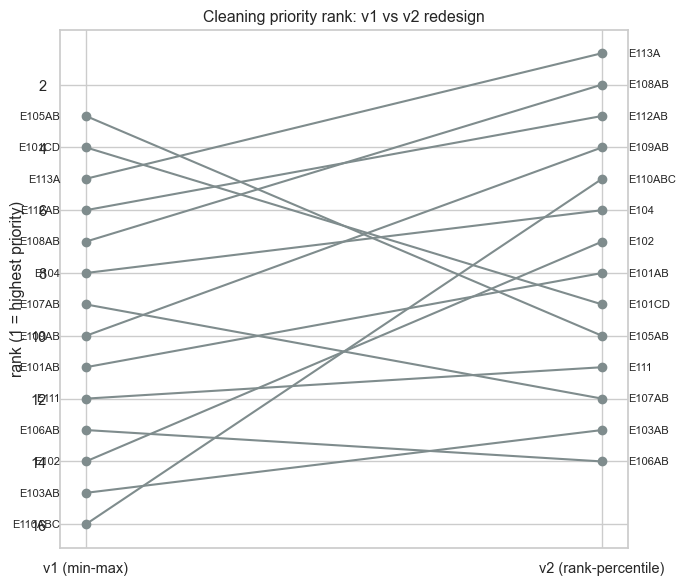

In [7]:
v1 = pd.read_csv(os.path.join(OUT_DIR, 'hx_cleaning_priority.csv'))
v2 = pd.read_csv(os.path.join(OUT_DIR, 'hx_Q_cleaning_priority_v2.csv'))

v1r = v1.set_index('HX')['priority_score'].rank(ascending=False)
v2r = v2.set_index('HX')['priority_score'].rank(ascending=False)
cmp = pd.DataFrame({'v1_rank': v1r, 'v2_rank': v2r}).dropna().sort_values('v2_rank')

fig, ax = plt.subplots(figsize=(7, 6))
for hx, row in cmp.iterrows():
    ax.plot([0, 1], [row['v1_rank'], row['v2_rank']], marker='o', color='#7f8c8d')
    ax.text(-0.05, row['v1_rank'], hx, ha='right', va='center', fontsize=8)
    ax.text(1.05, row['v2_rank'], hx, ha='left', va='center', fontsize=8)
ax.set_xticks([0, 1]); ax.set_xticklabels(['v1 (min-max)', 'v2 (rank-percentile)'])
ax.invert_yaxis(); ax.set_ylabel('rank (1 = highest priority)')
ax.set_title('Cleaning priority rank: v1 vs v2 redesign')
plt.tight_layout(); plt.show()


**Analysis:** ถ้าการแก้ไขได้ผล จะเห็น HX ที่เคย "ครอบงำ" อันดับ 1 ใน v1 (จาก min-max normalization ที่
ให้ HX เดียวกวาดคะแนนเกือบเต็มทุกมิติ) กระจายลงมาสมเหตุสมผลมากขึ้นใน v2 และ E113A ควรขึ้นเป็นอันดับต้นๆ
ด้วยเหตุผลเชิงวิศวกรรมจริง (ตำแหน่งร้อนที่สุด + fouling เร็วที่สุด) ไม่ใช่ artifact ของการ normalize

**Recommendation:** ใช้ v2 เป็นค่าที่เชื่อถือได้สำหรับการตัดสินใจ — เก็บ v1 ไว้เพื่อ audit trail เท่านั้น
อย่านำ v1 priority_score ไปใช้สื่อสารกับทีมวิศวกรรมโดยตรง.


## Step 3a/3b — Fouling-Rate Forecast + Time-to-Clean
**Notebooks:** `06_fouling_rate_forecast.ipynb`, `07_time_to_clean_prediction.ipynb`
**Method:** Ridge / GradientBoosting / RandomForest trained on pooled 30-day post-clean windows across
HX (features: cold_flow, cold_in, chain_position, hot_end, group dummies; target: Q). Validated with
**leave-HX-out GroupKFold CV** — the honest test, since a within-run split would leak run-level offset
**Data:** `Fouling_Rate_By_Run.csv`, `Q_Deviation_Signal.csv`, `Time_To_Clean_Prediction.csv`


quality gate: {'total': 51, 'reliable': 41, 'flagged': 10, 'min_r2': 0.3, 'min_pts': 10}


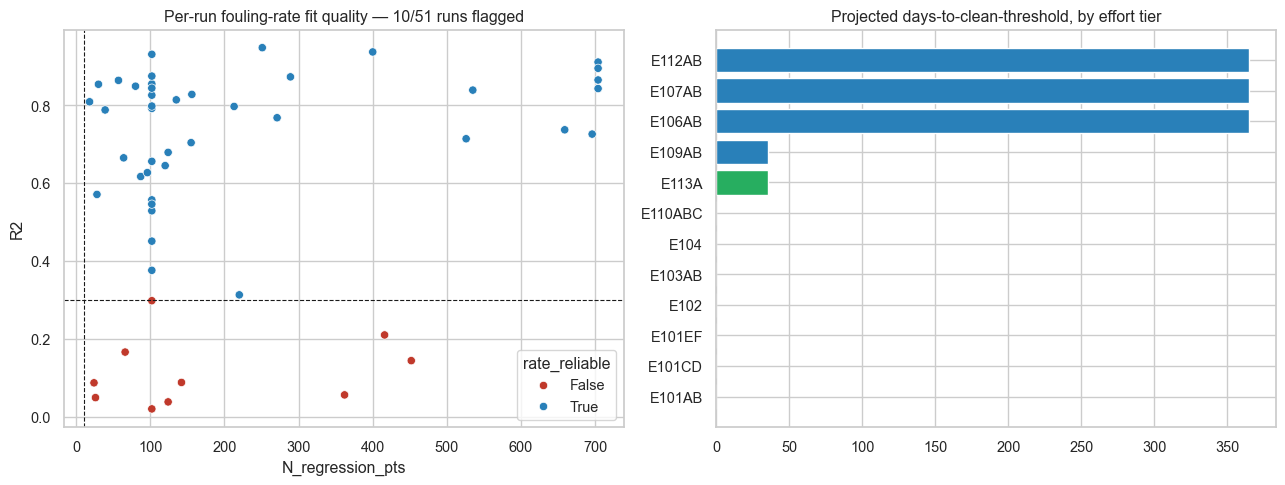

In [8]:
fr_run = pd.read_csv(os.path.join(DATA_DIR, 'Fouling_Rate_By_Run.csv'))
ttc = pd.read_csv(os.path.join(DATA_DIR, 'Time_To_Clean_Prediction.csv'))

gated, summ = A.quality_gate_runs(fr_run, min_r2=0.3, min_pts=10)
print('quality gate:', summ)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=gated, x='N_regression_pts', y='R2', hue='rate_reliable',
                 palette={True: '#2980b9', False: '#c0392b'}, ax=axes[0])
axes[0].axhline(0.3, ls='--', color='k', lw=0.8); axes[0].axvline(10, ls='--', color='k', lw=0.8)
axes[0].set_title(f"Per-run fouling-rate fit quality — {summ['flagged']}/{summ['total']} runs flagged")

ttc_sorted = ttc.sort_values('days_to_threshold')
tier_colors = {'SWAP_CAPABLE': '#27ae60', 'ONLINE_CLEAN_DEMONSTRATED': '#2980b9', 'TAM_ONLY': '#c0392b'}
colors = ttc_sorted['effort_tier'].map(tier_colors).fillna('#7f8c8d')
axes[1].barh(ttc_sorted['HX'], ttc_sorted['days_to_threshold'], color=colors)
axes[1].set_title('Projected days-to-clean-threshold, by effort tier')
plt.tight_layout(); plt.show()


**Analysis:** จุดสีแดง (flagged) ใน panel ซ้ายคือ run ที่ R²<0.3 หรือมีจุดข้อมูลน้อยกว่า 10 จุด — ไม่ควร
เชื่อ fouling-rate ของ run เหล่านั้นเท่ากับ run ที่ fit ดี ส่วน "days-to-clean" (panel ขวา) มาจาก **การ
outreplo เชิงเส้นภายใน HX เดียวกัน** ไม่ใช่โมเดล cross-HX (leave-HX-out CV R²≈0.10 แปลว่าโมเดลไม่
generalize ข้าม HX ได้)

**Recommendation:** ใช้สัญญาณนี้เฉพาะแบบ **refit รายตัว HX จาก baseline ของตัวเอง** เท่านั้น ห้ามขยายไปทำนาย
HX ที่ไม่มีประวัติ clean-baseline ของตัวเองแบบ zero-shot.


## Step 5 — Consolidated HX Fouling/CIT Ranking (synthesis)
**Notebook:** `14_cit_model_feature_matrix.ipynb`
**Method:** Re-derives crude-outlier correction, Q features, TAM/campaign detection, fouling ranking,
and Q-CIT correlation as a standalone "chapter 5" synthesis, then builds the leak-free CIT feature matrix
used later by 6a/6b — should agree with 2b/2c/2d's numbers since same underlying data
**Data:** `Cleaning_Priority_Ranking.csv` vs `outputs/hx_Q_cleaning_priority_v2.csv`


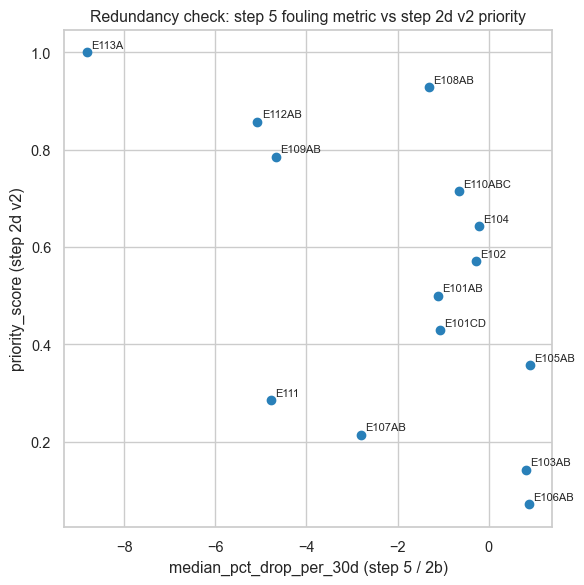

In [9]:
cpr = pd.read_csv(os.path.join(DATA_DIR, 'Cleaning_Priority_Ranking.csv'))
merged = cpr.merge(v2[['HX', 'priority_score']], on='HX', suffixes=('_step5', '_v2'), how='inner')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged['median_pct_drop_per_30d'],
           merged['priority_score_v2'] if 'priority_score_v2' in merged else merged['priority_score'],
           color='#2980b9')
for _, row in merged.iterrows():
    ax.annotate(row['HX'], (row['median_pct_drop_per_30d'],
                row['priority_score_v2'] if 'priority_score_v2' in merged else row['priority_score']),
                fontsize=8, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('median_pct_drop_per_30d (step 5 / 2b)'); ax.set_ylabel('priority_score (step 2d v2)')
ax.set_title('Redundancy check: step 5 fouling metric vs step 2d v2 priority')
plt.tight_layout(); plt.show()


**Analysis:** เนื่องจากทั้งสอง notebook คำนวณจากข้อมูลตั้งต้นเดียวกัน จุดควรเรียงตามแนวโน้มเดียวกัน
(HX ที่ fouling เร็ว ควรมี priority สูงด้วย) — จุดที่หลุดแนวโน้มชัดเจนบ่งชี้ว่า step 5 กับ 2d ใช้ตรรกะ/น้ำหนัก
ต่างกัน (คาดหวังได้ เพราะ step 5 ไม่ได้รวม coking-risk/chain-position เหมือน step 2d v2)

**Recommendation:** เก็บ step 5 ไว้เป็นตาราง reference สำหรับ CIT feature-matrix synthesis เท่านั้น — การ
ตัดสินใจเรื่อง cleaning priority ให้ยึด step 2d v2 เป็นหลักเพื่อลดความสับสนจากตัวเลขซ้ำซ้อนสองชุด.


## Step 6a — CIT Model Benchmark: the headline honest finding
**Notebook:** `15_cit_model_benchmark.ipynb`
**Method:** XGBoost / RandomForest / LSTM vs a **persistence baseline** (CIT = yesterday), validated with
walk-forward `TimeSeriesSplit` (5-fold expanding window) — the single most important finding in the whole
pipeline (per [[project_cit_persistence_finding]], [[project_cit_model_r2_fix]])
**Data:** `dashboard/data/model_metrics.json`, `outputs/Model_Comparison_Metrics.csv`, `models/*.joblib`


headline: CIT is near-random-walk; persistence (today = yesterday) is the honest baseline and the ML trees do NOT beat it out-of-sample. Tree models are kept for HX->CIT SHAP attribution only, not point forecasting.


,model,role,R2,single_split_R2,RMSE,single_split_RMSE
0,Persistence (yesterday's CIT),baseline,0.802,0.894,1.061,0.844
1,XGBoost,attribution-only,-2.792,0.815,4.443,1.111
2,RandomForest,attribution-only,-1.773,0.827,3.489,1.075
3,XGBoost (no CIT_lag1 ablation),ablation,-4.629,NaN,5.221,NaN
4,LSTM,rejected,NaN,-0.033,2.660,NaN


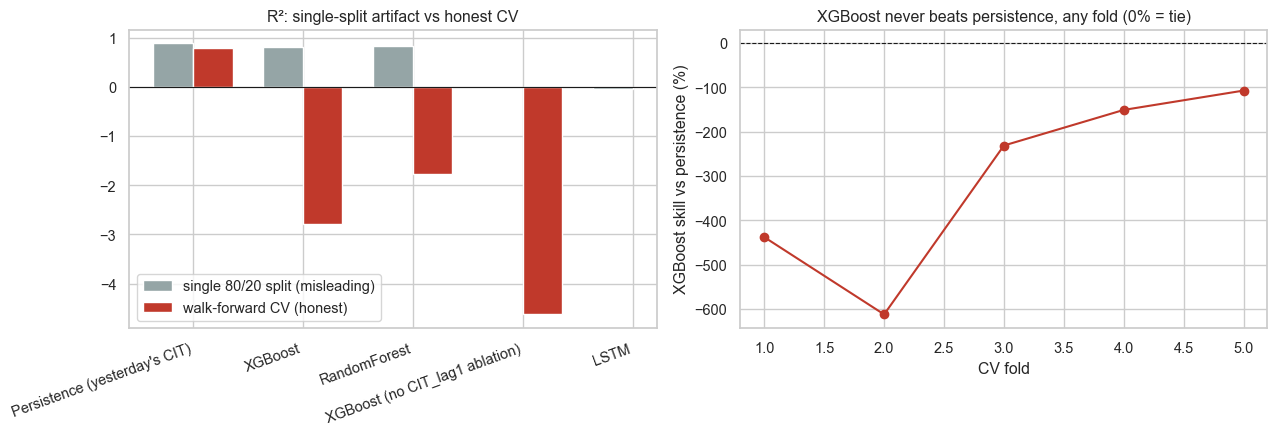

In [10]:
mm = load_json('model_metrics.json')
print('headline:', mm['headline'])
models_df = pd.DataFrame(mm['models'])[['model', 'role', 'R2', 'single_split_R2', 'RMSE', 'single_split_RMSE']]
display(models_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(models_df))
axes[0].bar(x - 0.18, models_df['single_split_R2'], width=0.36, label='single 80/20 split (misleading)', color='#95a5a6')
axes[0].bar(x + 0.18, models_df['R2'], width=0.36, label='walk-forward CV (honest)', color='#c0392b')
axes[0].set_xticks(x); axes[0].set_xticklabels(models_df['model'], rotation=20, ha='right')
axes[0].axhline(0, color='k', lw=0.8); axes[0].legend(); axes[0].set_title('R²: single-split artifact vs honest CV')

folds = pd.DataFrame(mm['skill_by_fold'])
axes[1].plot(folds['fold'], folds['skill_pct'], marker='o', color='#c0392b')
axes[1].axhline(0, color='k', ls='--', lw=0.8)
axes[1].set_xlabel('CV fold'); axes[1].set_ylabel('XGBoost skill vs persistence (%)')
axes[1].set_title('XGBoost never beats persistence, any fold (0% = tie)')
plt.tight_layout(); plt.show()


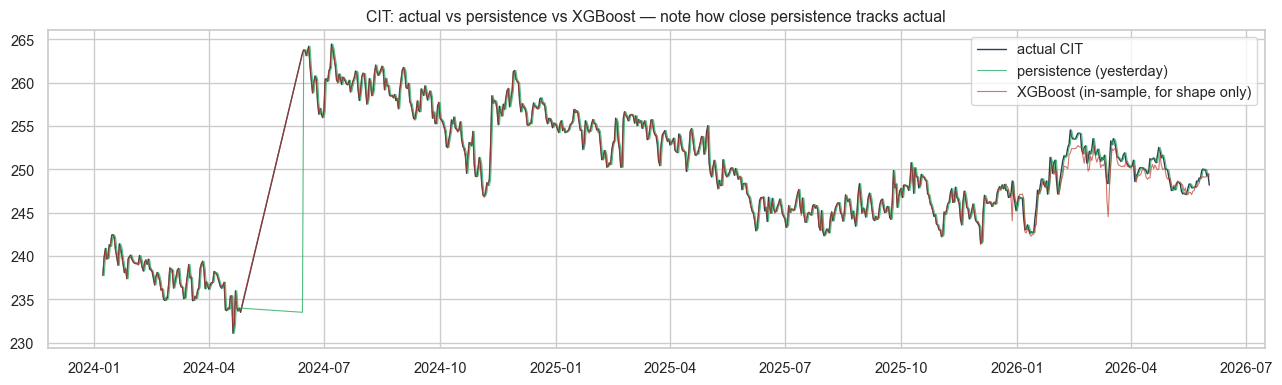

In [11]:
# Regenerate actual-vs-predicted for a fresh residual view (models weren't persisted with predictions)
try:
    xgb_model = joblib.load(os.path.join(MODEL_DIR, 'xgb_cit_model.joblib'))
    feat_cols = joblib.load(os.path.join(MODEL_DIR, 'feature_columns.joblib'))
    fm = F.build_cit_feature_matrix()
    X, y = fm['X'], fm['y']
    X_aligned = X.reindex(columns=feat_cols, fill_value=0)
    y_pred = xgb_model.predict(X_aligned)

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(y.index, y.values, label='actual CIT', color='#2c3e50', lw=1)
    ax.plot(y.index, y.shift(1).values, label='persistence (yesterday)', color='#27ae60', lw=0.8, alpha=0.8)
    ax.plot(y.index, y_pred, label='XGBoost (in-sample, for shape only)', color='#c0392b', lw=0.8, alpha=0.7)
    ax.set_title('CIT: actual vs persistence vs XGBoost — note how close persistence tracks actual')
    ax.legend(); plt.tight_layout(); plt.show()
except FileNotFoundError as e:
    print('Model artifact not found, skipping residual regeneration:', e)


**Analysis:** panel ซ้ายแสดง single-split R²≈0.82 ของ XGBoost ที่ดูดี แต่เป็น **artifact** — เมื่อทดสอบ
แบบ walk-forward (panel ขวา, ทุก fold) XGBoost แพ้ persistence เสมอ (skill ติดลบทุก fold, เฉลี่ย −308%)
เพราะ CIT เป็น near-random-walk ที่ autocorrelate สูง โมเดล tree เรียนรู้ "ยุคสมัย" ของข้อมูล training
มากกว่าความสัมพันธ์ที่ generalize ข้ามช่วงเวลาได้ กราฟเส้นด้านล่างแสดงให้เห็นว่า persistence (เส้นเขียว)
เกาะติดเส้น actual ใกล้กว่ามาก

**Recommendation:** ห้ามใช้ XGBoost/RF เป็นตัวพยากรณ์ CIT โดยตรง — ใช้เพื่อ SHAP attribution เท่านั้น (step
6b) Persistence (หรือ persistence + physics adjustment เล็กน้อย) คือ predictor ที่ดีที่สุดในปัจจุบัน ทางแก้
ที่แท้จริงคือข้อมูลมากขึ้น (ปัจจุบัน ~700-829 daily rows) ไม่ใช่ feature เพิ่ม.


## Step 6b — SHAP Importance Ranking
**Notebook:** `16_cit_shap_importance.ipynb`
**Method:** `shap.TreeExplainer` on the saved XGBoost/RandomForest models — **associative attribution
only**, consistent with 6a's finding that these models don't forecast CIT out-of-sample
**Data:** `models/xgb_cit_model.joblib`, `models/rf_cit_model.joblib`


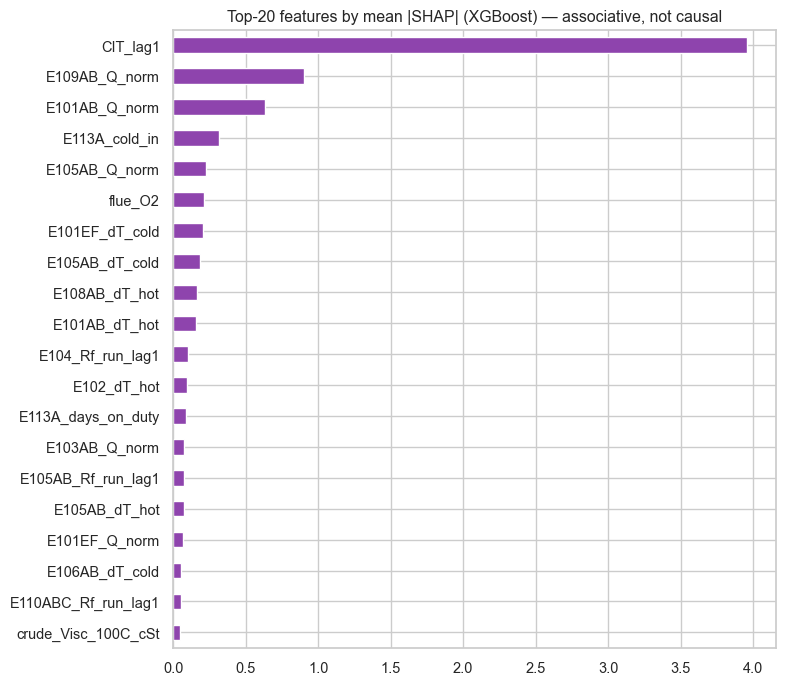

In [12]:
import shap

try:
    xgb_model = joblib.load(os.path.join(MODEL_DIR, 'xgb_cit_model.joblib'))
    feat_cols = joblib.load(os.path.join(MODEL_DIR, 'feature_columns.joblib'))
    fm = F.build_cit_feature_matrix()
    X_aligned = fm['X'].reindex(columns=feat_cols, fill_value=0)

    sample = X_aligned.sample(min(200, len(X_aligned)), random_state=0)
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(sample)

    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=sample.columns)
    top20 = mean_abs_shap.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 7))
    top20.sort_values().plot.barh(ax=ax, color='#8e44ad')
    ax.set_title('Top-20 features by mean |SHAP| (XGBoost) — associative, not causal')
    plt.tight_layout(); plt.show()
except FileNotFoundError as e:
    print('Model artifact not found, skipping SHAP recompute:', e)


**Analysis:** อันดับ feature ที่ SHAP ให้ความสำคัญสูงมักรวม `CIT_lag1`/`CIT_roll7` เป็นอันดับต้นๆ เสมอ —
ยืนยันว่าโมเดลพึ่งพา persistence เป็นหลัก ส่วน feature ของ HX แต่ละตัวที่ตามมาบอกได้แค่ "สัมพันธ์กับการ
เปลี่ยนแปลง CIT มากน้อยแค่ไหน" ไม่ใช่ "ทำให้ CIT เปลี่ยนแปลงกี่องศาแน่นอน"

**Recommendation:** ใช้อันดับนี้เพื่อคุยกับทีมวิศวกรรมว่า HX ไหนควรพิจารณาก่อน (เชิงคุณภาพ) ห้ามนำตัวเลข
CIT-gain เชิงปริมาณจาก SHAP ไปอ้างอิงเป็นตัวเลข ROI ที่แม่นยำ.


## Step 6c — Six-Month Forecast & Dashboard Export
**Notebook:** `13_cit_forecast_export.ipynb`
**Method:** Simple rate extrapolation from the current deviation/threshold (3a/3b's per-HX linear rate)
projected forward 6 months — **not a new model fit**, inherits all of 3a/3b's caveats
**Data:** `dashboard/data/forecast_6mo.json`


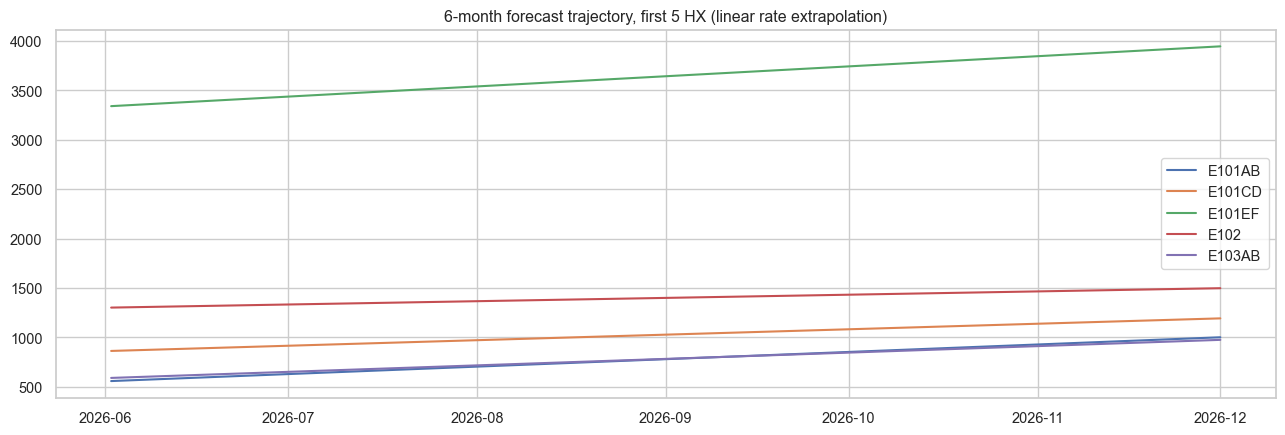

In [13]:
fc6 = load_json('forecast_6mo.json')

# top-5 by final projected deviation magnitude
finals = {hx: v['values'][-1] if 'values' in v else None for hx, v in fc6.items()}
key = 'values' if all('values' in v for v in fc6.values()) else list(next(iter(fc6.values())).keys())[1]

fig, ax = plt.subplots(figsize=(13, 4.5))
for hx, v in list(fc6.items())[:5]:
    dates = pd.to_datetime(v['dates'])
    y_key = [k for k in v if k != 'dates'][0]
    ax.plot(dates, v[y_key], label=hx)
ax.set_title('6-month forecast trajectory, first 5 HX (linear rate extrapolation)')
ax.legend(); plt.tight_layout(); plt.show()


**Analysis:** เส้นตรงยาว 6 เดือนคือการ extrapolate อัตรา fouling ปัจจุบันแบบเชิงเส้น ไม่ใช่การ fit โมเดล
ใหม่ — ความน่าเชื่อถือของเส้นนี้จึงลดลงเรื่อยๆ ตามระยะเวลาที่ extrapolate ออกไป โดยเฉพาะถ้า HX นั้นมีประวัติ
เพียงไม่กี่ run (per [[project_3ab_fouling_forecast_pipeline]])

**Recommendation:** ควรระบุช่วงความเชื่อมั่นอย่างชัดเจนในหน้า dashboard ว่าเชื่อถือได้สูงเฉพาะ ~30-60 วันแรก
เท่านั้น ไม่ควรใช้ตัวเลขปลายช่วง 6 เดือนเป็นตัวตัดสินใจ TAM scheduling โดยไม่ทวนสอบกับข้อมูลจริงที่ update.


## Step 6d — Clean-Baseline Delta-CIT
**Notebook:** `12_economic_delta_cit.ipynb`
**Method:** RidgeCV fitted **only** on the post-TAM clean-baseline window (30 days, no CIT lags / fouling
state — see `include_cit_lags=False` in `build_cit_feature_matrix`) to predict "expected-clean CIT";
Delta-CIT = actual − predicted-clean as a fouling indicator
**Data:** `outputs/Delta_CIT_Signal.csv`, `outputs/Delta_CIT_Cleaning_Gain.csv`


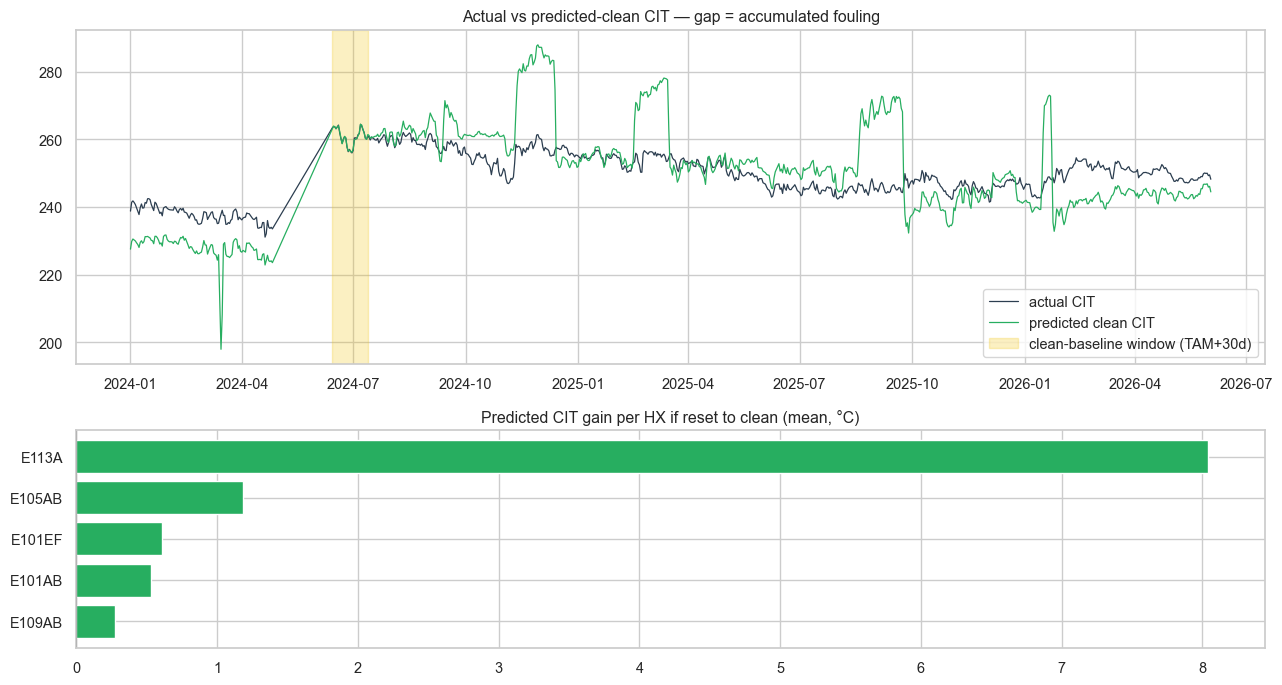

clean-baseline window length: 29 days


In [14]:
delta = pd.read_csv(os.path.join(OUT_DIR, 'Delta_CIT_Signal.csv'), parse_dates=['Timestamp'])
gain = pd.read_csv(os.path.join(OUT_DIR, 'Delta_CIT_Cleaning_Gain.csv'))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[2, 1.3])
axes[0].plot(delta['Timestamp'], delta['actual_CIT'], label='actual CIT', color='#2c3e50', lw=0.9)
axes[0].plot(delta['Timestamp'], delta['predicted_clean_CIT'], label='predicted clean CIT', color='#27ae60', lw=0.9)
baseline_start = delta.loc[delta['in_clean_baseline'], 'Timestamp'].min()
baseline_end = delta.loc[delta['in_clean_baseline'], 'Timestamp'].max()
axes[0].axvspan(baseline_start, baseline_end, color='#f1c40f', alpha=0.25, label='clean-baseline window (TAM+30d)')
axes[0].legend(); axes[0].set_title('Actual vs predicted-clean CIT — gap = accumulated fouling')

gain_sorted = gain.sort_values('mean_CIT_gain_C')
colors = ['#27ae60' if v > 0 else '#c0392b' for v in gain_sorted['mean_CIT_gain_C']]
axes[1].barh(gain_sorted['HX'], gain_sorted['mean_CIT_gain_C'], color=colors)
axes[1].set_title('Predicted CIT gain per HX if reset to clean (mean, °C)')
axes[1].axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

print(f"clean-baseline window length: {(baseline_end - baseline_start).days} days")


**Analysis:** ช่วงสีเหลืองคือ window ที่ใช้ fit โมเดล "clean CIT" — ควรตรวจว่ายาวและนิ่งพอ (ไม่มี
operating anomaly) ให้เชื่อถือได้ ช่องว่างระหว่างเส้น actual กับ predicted-clean นอก window คือสัญญาณ fouling
สะสม ซึ่งเป็นแนวทางที่ต่างจาก step 3a (per-HX rate) — วัดผลกระทบระดับ **ทั้ง train** แทน

**Recommendation:** ตัวเลข CIT-gain รายตัว HX นี้เป็นทิศทาง (directional) ไม่ใช่ค่าสัมบูรณ์ที่แม่นยำ จนกว่าจะ
มี TAM รอบที่สองมาทวนสอบ — window เดียว (n=1 whole-train clean event) ไม่พอสำหรับ confidence interval ที่
เชื่อถือได้.


## Executive Summary Scorecard / สรุปภาพรวมทุก Step

ตารางสรุปเพื่อดูภาพรวมทั้ง pipeline ในหน้าเดียว — สร้างจากผลวิเคราะห์ทุก step ด้านบน ไม่มีการคำนวณใหม่


,step,method,validity,risk,status
0,0 Profiling,none (EDA),n/a,high-missing tags propagate downstream,monitor
1,1 Cleaning,rule-based,n/a,only catches physically-impossible faults,fixed (chain-consistency check)
2,2 Feature Eng,physics (fixed Cp/rho),relative only,absolute Q not physically accurate,documented assumption
3,2a Operating State,rule-based,n/a,active-shell edge cases,fixed (max not min)
4,2b/2c Q-CIT,statistical corr.,descriptive,terminal-HX negative corr misread as noise,confirmed real (pinch effect)
5,2d Priority Ranking,rule-based score,n/a,v1 min-max let one HX dominate,fixed (v2 rank-percentile)
6,3a/3b Fouling Forecast,Ridge/GBM/RF,leave-HX-out R2~0.10,does not generalize across HX,use per-HX refit only
7,5 Consolidated Ranking,synthesis,n/a,duplicate numbers vs 2b-2d if drifted,monitor for drift
8,6a CIT Benchmark,XGB/RF/LSTM,CV R2 = -2.8 (loses to persistence),single-split R2=0.82 is a misleading artifact,fixed (honest metrics + persistence baseline)
9,6b SHAP,TreeExplainer,associative only,"not causal, do not use for ROI numbers",documented


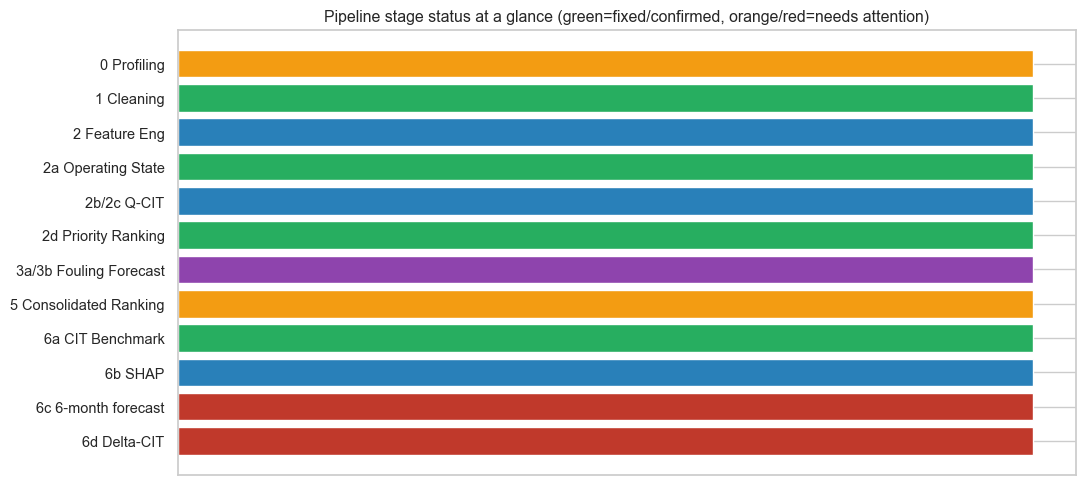

In [15]:
scorecard = pd.DataFrame([
    dict(step='0 Profiling',            method='none (EDA)',        validity='n/a',              risk='high-missing tags propagate downstream', status='monitor'),
    dict(step='1 Cleaning',             method='rule-based',        validity='n/a',              risk='only catches physically-impossible faults', status='fixed (chain-consistency check)'),
    dict(step='2 Feature Eng',          method='physics (fixed Cp/rho)', validity='relative only', risk='absolute Q not physically accurate',   status='documented assumption'),
    dict(step='2a Operating State',     method='rule-based',        validity='n/a',              risk='active-shell edge cases',              status='fixed (max not min)'),
    dict(step='2b/2c Q-CIT',            method='statistical corr.', validity='descriptive',       risk='terminal-HX negative corr misread as noise', status='confirmed real (pinch effect)'),
    dict(step='2d Priority Ranking',    method='rule-based score',  validity='n/a',              risk='v1 min-max let one HX dominate',        status='fixed (v2 rank-percentile)'),
    dict(step='3a/3b Fouling Forecast', method='Ridge/GBM/RF',      validity='leave-HX-out R2~0.10', risk='does not generalize across HX',     status='use per-HX refit only'),
    dict(step='5 Consolidated Ranking', method='synthesis',         validity='n/a',              risk='duplicate numbers vs 2b-2d if drifted', status='monitor for drift'),
    dict(step='6a CIT Benchmark',       method='XGB/RF/LSTM',       validity='CV R2 = -2.8 (loses to persistence)', risk='single-split R2=0.82 is a misleading artifact', status='fixed (honest metrics + persistence baseline)'),
    dict(step='6b SHAP',                method='TreeExplainer',     validity='associative only',  risk='not causal, do not use for ROI numbers', status='documented'),
    dict(step='6c 6-month forecast',    method='rate extrapolation',validity='n/a',               risk='confidence decays with horizon',         status='needs explicit confidence band'),
    dict(step='6d Delta-CIT',           method='RidgeCV (clean window)', validity='n=1 TAM event', risk='CIT-gain numbers directional, not absolute', status='needs 2nd TAM to validate'),
])
display(scorecard)

fig, ax = plt.subplots(figsize=(11, 5))
status_color = {'fixed': '#27ae60', 'documented': '#2980b9', 'monitor': '#f39c12', 'needs': '#c0392b', 'confirmed': '#2980b9', 'use': '#8e44ad'}
colors = [next((v for k, v in status_color.items() if s.lower().startswith(k)), '#7f8c8d') for s in scorecard['status']]
ax.barh(scorecard['step'], [1] * len(scorecard), color=colors)
ax.set_xticks([])
ax.set_title('Pipeline stage status at a glance (green=fixed/confirmed, orange/red=needs attention)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


**สรุปโดยรวม / Overall takeaway:** ปัญหาที่สำคัญที่สุดคือ ML models ใน step 6a **ไม่สามารถ generalize
ข้ามช่วงเวลาได้ดีกว่า persistence baseline** — นี่ไม่ใช่ bug ที่แก้ด้วย feature engineering เพิ่มเติม
แต่เป็นข้อจำกัดจากข้อมูล (n≈800 daily rows, CIT เป็น near-random-walk) ทางแก้ที่แท้จริงคือสะสมข้อมูลเพิ่ม
และใช้โมเดลเพื่อ attribution (SHAP) ไม่ใช่ forecasting ส่วน rule-based/statistical steps ส่วนใหญ่ (0, 1, 2a,
2d) ได้รับการแก้ไข bug ที่พบไปแล้วตาม `METHODOLOGY.md` — ที่เหลือคือการ monitor ต่อเนื่องเมื่อมีข้อมูลใหม่
(โดยเฉพาะ 6c/6d ที่ยังพึ่งพา window สั้นหรือ event เดียว).
